# Task 1 — Air Quality Forecasting
**Candidate:** Saran Mathesh  
**Goal:** Predict the next hour's ground-truth carbon monoxide concentration (`CO(GT)`) from measurements available at the current hour and earlier.

> This notebook downloads the UCI Air Quality dataset when run. Run all cells from top to bottom. The forecasting target is shifted one row into the future; feature columns use only current/past observations.

## 1. Imports and reproducibility

In [13]:
import io, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore")

## 2. Load and inspect the UCI dataset
The UCI file contains hourly air-quality measurements. The value `-200` is used in this dataset as a missing-value sentinel, so it must not be treated as a real measurement.

In [14]:
url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
with urllib.request.urlopen(url) as response:
    archive_bytes = response.read()

with zipfile.ZipFile(io.BytesIO(archive_bytes)) as zf:
    excel_name = next(n for n in zf.namelist() if n.lower().endswith((".xlsx", ".xls")))
    with zf.open(excel_name) as f:
        raw = pd.read_excel(f)

print("Raw shape:", raw.shape)
display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.isna().sum().to_frame("missing_count"))

Raw shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


,dtype
Date,datetime64[ns]
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),int64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


,missing_count
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


## 3. Clean timestamps and invalid/missing values
The source stores date and time in separate columns. We combine them into a timestamp, sort chronologically, convert `-200` to missing values, and remove duplicate timestamps. Invalid sensor values are not guessed; missing predictor values are imputed within a modeling pipeline fitted only on the training data.

In [15]:
df = raw.copy()
df.columns = [str(c).strip() for c in df.columns]

# Parse the source's separate date/time fields.
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
time_text = df["Time"].astype(str).str.strip()
df["Time"] = pd.to_datetime(time_text, format="%H.%M.%S", errors="coerce").dt.time
df["timestamp"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d") + " " + time_text.str.replace(".", ":", regex=False),
    errors="coerce"
)
# Verify timestamp quality

print("Missing timestamps:", df["timestamp"].isna().sum())

# Check for duplicate timestamps
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Check hourly continuity
time_gaps = df["timestamp"].diff()

non_hourly = (
    time_gaps.notna() &
    (time_gaps != pd.Timedelta(hours=1))
)

print("Non-hourly intervals:", non_hourly.sum())

# Display examples of irregular intervals
display(
    df.loc[non_hourly, ["timestamp"]].head(10)
)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
df = df.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)

# Convert numeric columns and replace the documented sentinel.
for col in df.columns:
    if col not in ["Date", "Time", "timestamp"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.replace(-200, np.nan)

print("Cleaned source shape:", df.shape)
print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Missing timestamps: 0
Duplicate timestamps: 0
Non-hourly intervals: 0


,timestamp


Cleaned source shape: (9357, 16)
Time range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Duplicate timestamps: 0


,missing_count
Time,9357
NMHC(GT),8443
CO(GT),1683
NO2(GT),1642
NOx(GT),1639
C6H6(GT),366
PT08.S2(NMHC),366
PT08.S1(CO),366
T,366
PT08.S3(NOx),366


## 4. Exploratory data analysis

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.100000,1.100000,1.800000,2.900000,11.900000
PT08.S1(CO),8991.0,1099.707856,217.084571,647.250000,936.750000,1063.000000,1231.250000,2039.750000
NMHC(GT),914.0,218.811816,204.459921,7.000000,67.000000,150.000000,297.000000,1189.000000
C6H6(GT),8991.0,10.082993,7.449640,0.149048,4.436942,8.239851,13.988478,63.741476
PT08.S2(NMHC),8991.0,939.029205,266.829000,383.250000,734.375000,909.000000,1116.250000,2214.000000
NOx(GT),7718.0,246.881252,212.971224,2.000000,98.000000,179.800000,326.000000,1479.000000
PT08.S3(NOx),8991.0,835.370973,256.815106,322.000000,657.875000,805.500000,969.250000,2682.750000
NO2(GT),7715.0,113.075515,48.359250,2.000000,78.000000,109.000000,142.000000,339.700000
PT08.S4(NO2),8991.0,1456.143486,346.204540,551.000000,1226.625000,1462.750000,1673.500000,2775.000000
PT08.S5(O3),8991.0,1022.780725,398.480897,221.000000,731.375000,963.250000,1273.375000,2522.750000


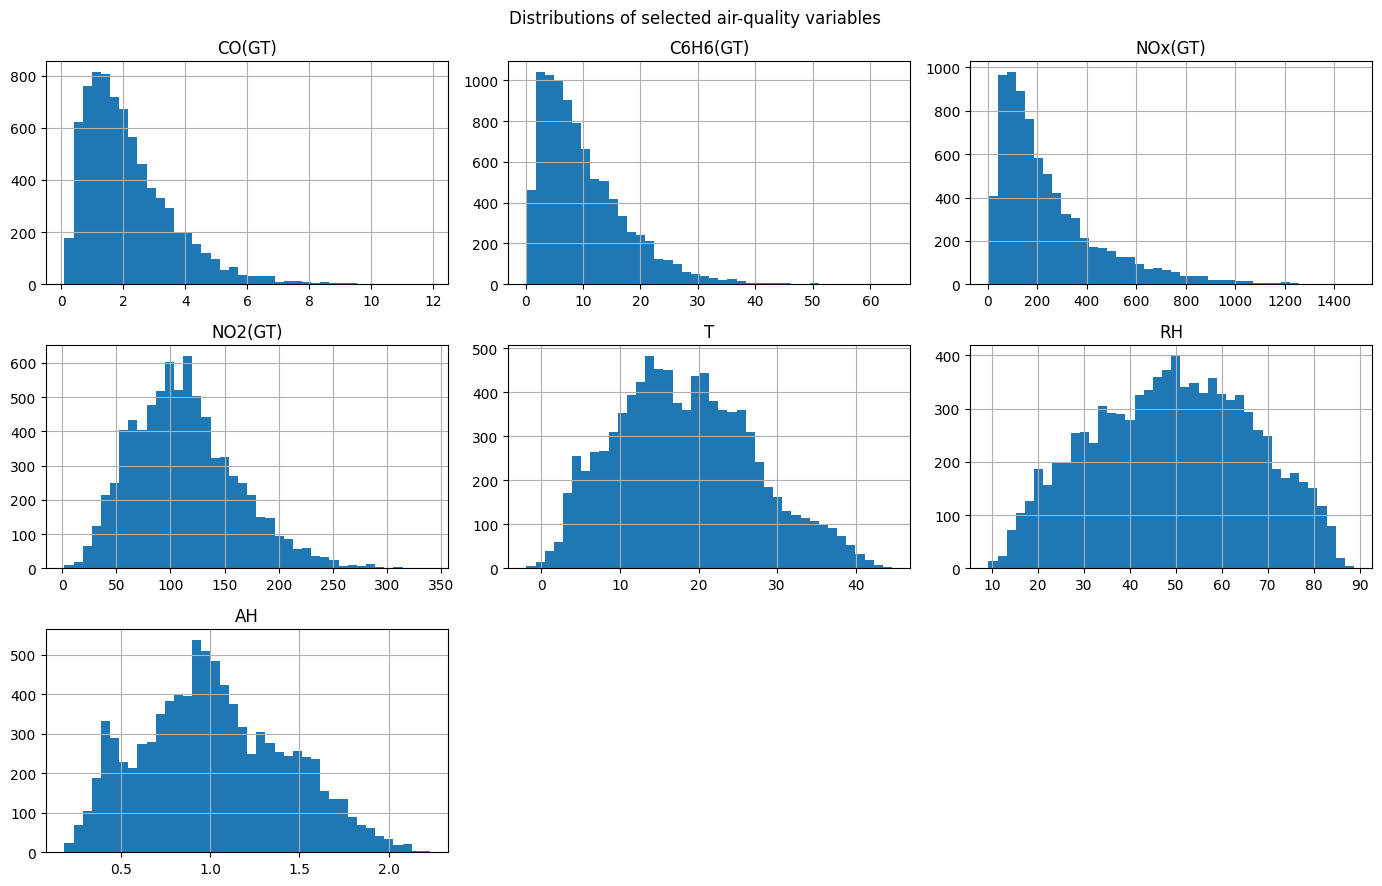

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

# Distributions for key measured pollutants/sensors.
plot_cols = [c for c in ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"] if c in df.columns]
df[plot_cols].hist(figsize=(14, 9), bins=40)
plt.suptitle("Distributions of selected air-quality variables")
plt.tight_layout()
plt.show()

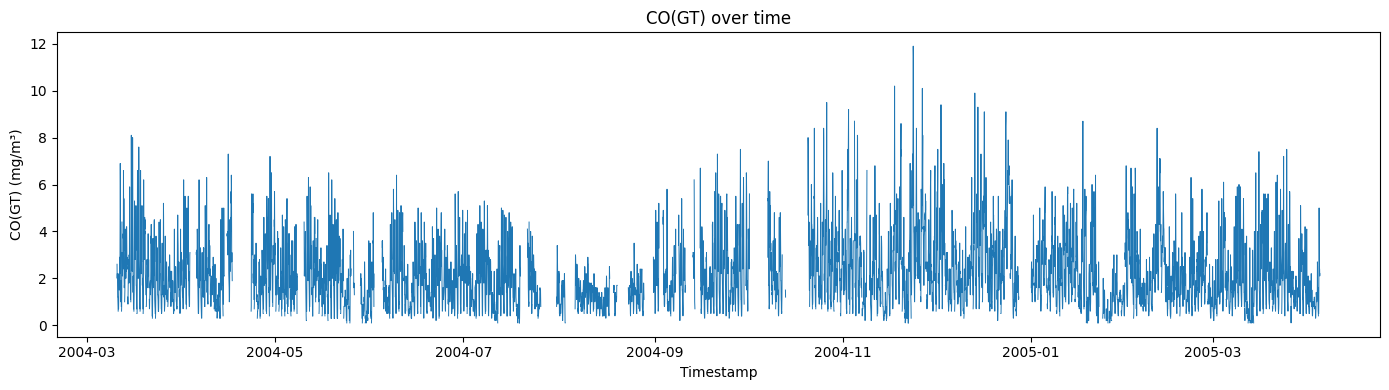

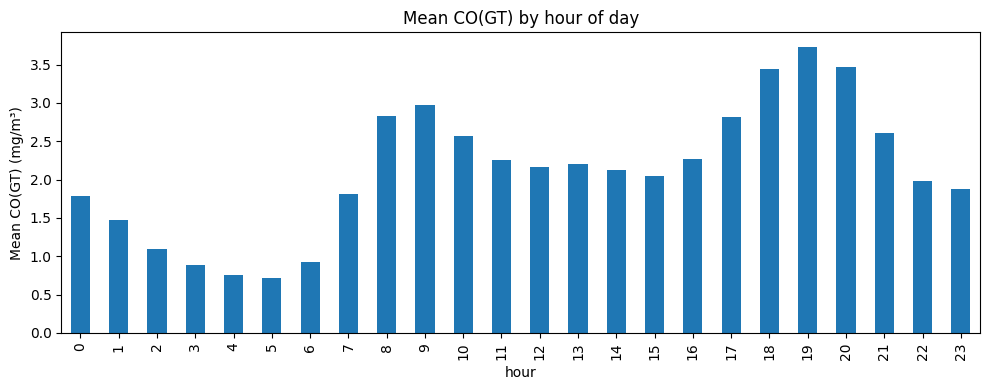

In [17]:
# Hourly trends: daily/hourly aggregates help reveal temporal patterns.
if "CO(GT)" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["timestamp"], df["CO(GT)"], linewidth=0.7)
    ax.set(title="CO(GT) over time", xlabel="Timestamp", ylabel="CO(GT) (mg/m³)")
    plt.tight_layout()
    plt.show()

df["hour"] = df["timestamp"].dt.hour
if "CO(GT)" in df.columns:
    hourly = df.groupby("hour")["CO(GT)"].mean()
    hourly.plot(kind="bar", figsize=(10, 4), title="Mean CO(GT) by hour of day")
    plt.ylabel("Mean CO(GT) (mg/m³)")
    plt.tight_layout()
    plt.show()

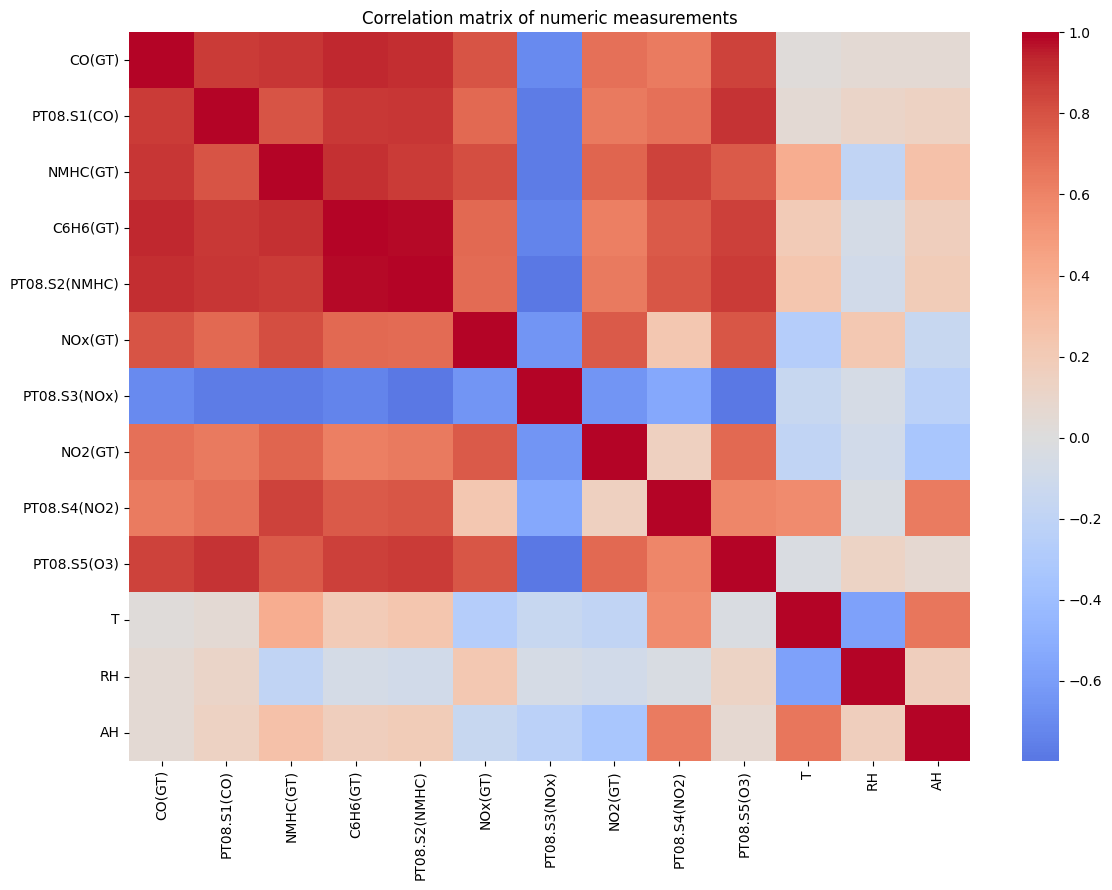

In [18]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix of numeric measurements")
plt.tight_layout()
plt.show()

## 5. Feature engineering and prediction target
**Target:** `CO(GT)` one row/hour ahead.  
**Features:** current sensor/environment readings, lags of CO(GT) and NOx(GT), rolling averages based only on current and previous observations, and calendar features.

The target uses `shift(-1)` only to create the label. No future value is included among the predictors. Rolling windows are shifted by one row so they contain observations strictly before the current timestamp; current measurements are also included as available-now inputs.

In [19]:
data = df.copy()
data = data.set_index("timestamp").sort_index()

target_col = "CO(GT)"
if target_col not in data.columns:
    raise ValueError(f"Expected target column {target_col!r} was not found.")

# Feature columns: measured numeric fields except the source's date/time helper columns.
sensor_cols = [c for c in data.select_dtypes(include=np.number).columns if c != target_col]
X = data[sensor_cols].copy()

# Include current CO and explicit lag/rolling features.
X["CO_current"] = data[target_col]
for lag in [1, 2, 3, 24]:
    X[f"CO_lag_{lag}"] = data[target_col].shift(lag)
if "NOx(GT)" in data.columns:
    for lag in [1, 2, 3]:
        X[f"NOx_lag_{lag}"] = data["NOx(GT)"].shift(lag)

for window in [3, 6, 24]:
    X[f"CO_rolling_mean_{window}"] = data[target_col].shift(1).rolling(window=window, min_periods=1).mean()

X["hour"] = data.index.hour
X["day_of_week"] = data.index.dayofweek
X["month"] = data.index.month

y = data[target_col].shift(-1).rename("CO_next_hour")

model_data = X.join(y).replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna(subset=["CO_next_hour"])
# Keep a chronological split; missing predictors are handled with train-fitted imputation.
X = model_data.drop(columns="CO_next_hour")
y = model_data["CO_next_hour"]

print("Feature matrix:", X.shape, "| Target:", y.shape)
display(X.head())

Feature matrix: (7673, 26) | Target: (7673,)


,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,CO_current,CO_lag_1,CO_lag_2,CO_lag_3,CO_lag_24,NOx_lag_1,NOx_lag_2,NOx_lag_3,CO_rolling_mean_3,CO_rolling_mean_6,CO_rolling_mean_24,day_of_week,month
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,18,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3
2004-03-10 19:00:00,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,19,2.0,2.6,NaN,NaN,NaN,166.0,NaN,NaN,2.600000,2.600000,2.600000,2,3
2004-03-10 20:00:00,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,20,2.2,2.0,2.6,NaN,NaN,103.0,166.0,NaN,2.300000,2.300000,2.300000,2,3
2004-03-10 21:00:00,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,21,2.2,2.2,2.0,2.6,NaN,131.0,103.0,166.0,2.266667,2.266667,2.266667,2,3
2004-03-10 22:00:00,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,22,1.6,2.2,2.2,2.0,NaN,172.0,131.0,103.0,2.133333,2.250000,2.250000,2,3


## 6. Chronological train/test split and baseline
A random split would mix later observations into training and make a time-series evaluation unrealistically optimistic. We reserve the final 20% of rows for testing. A training-mean baseline provides a reference point.

In [20]:
split_idx = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train period:", X_train.index.min(), "to", X_train.index.max())
print("Test period:", X_test.index.min(), "to", X_test.index.max())

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

Train: (6138, 26) Test: (1535, 26)
Train period: 2004-03-10 18:00:00 to 2005-01-29 05:00:00
Test period: 2005-01-29 06:00:00 to 2005-04-04 13:00:00


## 7. Train a Random Forest regressor
Median imputation is learned from training data only through the pipeline. Random Forest is a nonlinear model that can capture interactions between pollutants and weather-related measurements.

In [21]:
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

def regression_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(actual, predicted)
    }

results = pd.DataFrame({
    "Baseline (mean)": regression_metrics(y_test, baseline_pred),
    "Random Forest": regression_metrics(y_test, test_pred)
}).T
display(results.round(4))
# Persistence baseline: predict next-hour CO using current CO

baseline_pred = X_test["CO_current"]

# Evaluate on the same test observations as Random Forest

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Persistence Baseline Results")
print("MAE:", round(baseline_mae, 4))
print("MSE:", round(baseline_mse, 4))
print("RMSE:", round(baseline_rmse, 4))
print("R²:", round(baseline_r2, 4))
# Final comparison: Mean baseline, Persistence, Random Forest

comparison = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Persistence Baseline",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, baseline_mean_pred),
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, test_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, baseline_mean_pred),
        mean_squared_error(y_test, baseline_pred),
        mean_squared_error(y_test, test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, baseline_mean_pred)),
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        np.sqrt(mean_squared_error(y_test, test_pred))
    ],
    "R2": [
        r2_score(y_test, baseline_mean_pred),
        r2_score(y_test, baseline_pred),
        r2_score(y_test, test_pred)
    ]
})

display(comparison.round(4))

,MAE,MSE,RMSE,R²
Baseline (mean),1.0830,1.8431,1.3576,-0.0196
Random Forest,0.4181,0.3597,0.5997,0.8010


In [29]:
# Final model comparison on identical test observations

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Keep test rows with valid current CO
mask = X_test["CO_current"].notna()

# Align all predictions and actual values
y_eval = y_test.loc[mask]
persistence_pred = X_test.loc[mask, "CO_current"]
rf_pred = np.asarray(test_pred)[mask.to_numpy()]

# Mean baseline using training target mean
mean_pred = np.full(len(y_eval), y_train.mean())

# Evaluation function
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

# Compare all models on the same rows
comparison = pd.DataFrame({
    "Mean Baseline": evaluate(y_eval, mean_pred),
    "Persistence Baseline": evaluate(y_eval, persistence_pred),
    "Random Forest": evaluate(y_eval, rf_pred)
}).T

print("Test observations used:", len(y_eval))
print("Rows excluded due to missing current CO:", (~mask).sum())

display(comparison.round(4))

Test observations used: 1510
Rows excluded due to missing current CO: 25


,MAE,MSE,RMSE,R2
Mean Baseline,1.0750,1.8314,1.3533,-0.0155
Persistence Baseline,0.5148,0.6349,0.7968,0.6480
Random Forest,0.4198,0.3625,0.6020,0.7990


### Model Comparison and Conclusion

Three models were evaluated for next-hour CO concentration forecasting: a mean baseline, a persistence baseline, and a Random Forest regressor.

The mean baseline achieved an MAE of 1.0750 and an R² of −0.0155. The persistence baseline, which uses the current CO measurement to predict the next hour, achieved an MAE of 0.5148 and an R² of approximately 0.640.

The Random Forest achieved an MAE of 0.4198, an RMSE of 0.6020, and an R² of approximately 0.790 on the evaluated test subset.

The Random Forest reduced prediction errors compared with the persistence baseline, indicating that the additional pollutant, weather, and time-related features provide useful predictive information.

The comparison was performed on the same test observations with valid current CO measurements. These results demonstrate the model's predictive performance on this subset, but do not establish its performance under every future air-quality condition.


In [28]:
print("y_test shape:", y_test.shape)
print("X_test shape:", X_test.shape)
print("CO_current missing:", X_test["CO_current"].isna().sum())
print("y_test missing:", y_test.isna().sum())
print("test_pred shape:", np.shape(test_pred))

print("CO_current data type:", X_test["CO_current"].dtype)
print("y_test data type:", y_test.dtype)

y_test shape: (1535,)
X_test shape: (1535, 26)
CO_current missing: 25
y_test missing: 0
test_pred shape: (1535,)
CO_current data type: float64
y_test data type: float64


## 8. Prediction diagnostics

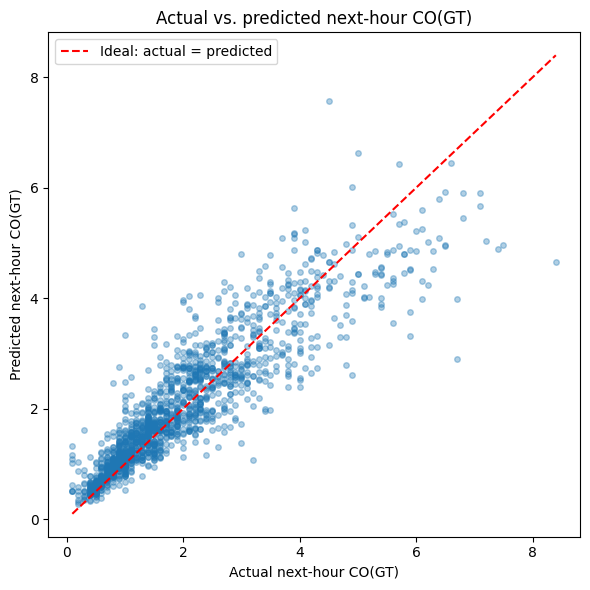

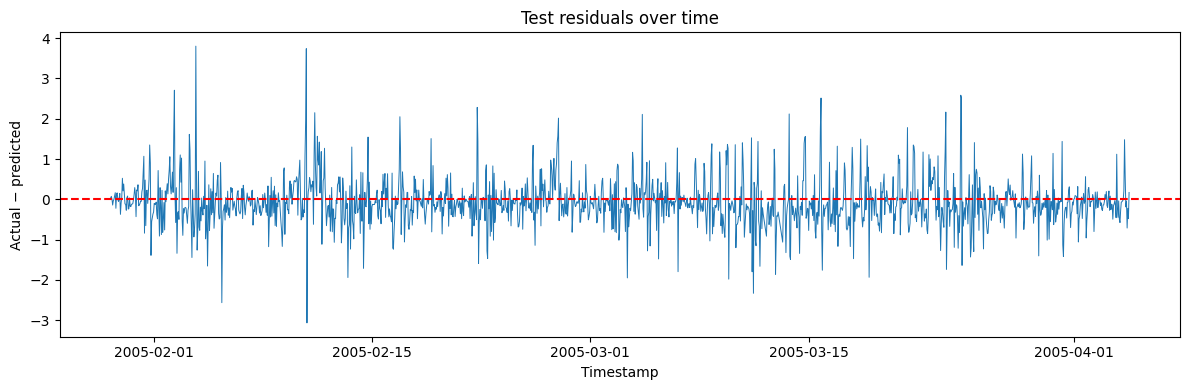

,actual,predicted,absolute_error
timestamp,,,
2005-02-03 17:00:00,6.7,2.899789,3.800211
2005-02-10 19:00:00,8.4,4.661018,3.738982
2005-02-10 20:00:00,4.5,7.564681,3.064681
2005-02-02 08:00:00,6.7,3.992988,2.707012
2005-03-24 18:00:00,5.9,3.316821,2.583179
2005-02-05 09:00:00,1.3,3.862869,2.562869
2005-03-24 19:00:00,7.5,4.972813,2.527187
2005-03-15 19:00:00,7.4,4.887026,2.512974
2005-03-11 11:00:00,1.0,3.330891,2.330891


In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, test_pred, alpha=0.35, s=16)
lo = min(float(y_test.min()), float(np.min(test_pred)))
hi = max(float(y_test.max()), float(np.max(test_pred)))
ax.plot([lo, hi], [lo, hi], "r--", label="Ideal: actual = predicted")
ax.set(xlabel="Actual next-hour CO(GT)", ylabel="Predicted next-hour CO(GT)",
       title="Actual vs. predicted next-hour CO(GT)")
ax.legend()
plt.tight_layout()
plt.show()

residuals = y_test - test_pred
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, residuals, linewidth=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Test residuals over time")
plt.xlabel("Timestamp")
plt.ylabel("Actual − predicted")
plt.tight_layout()
plt.show()

# Largest absolute errors for inspection.
error_table = pd.DataFrame({
    "actual": y_test,
    "predicted": test_pred,
    "absolute_error": np.abs(residuals)
}).sort_values("absolute_error", ascending=False)
display(error_table.head(10))

## 9. Feature importance
Permutation-free impurity importance is provided as a quick diagnostic. It can be biased toward features with many possible split points and should be interpreted as model-specific, not causal.

,importance
CO_current,0.619709
hour,0.066698
PT08.S2(NMHC),0.060842
C6H6(GT),0.052497
PT08.S1(CO),0.017261
CO_lag_1,0.016713
NOx(GT),0.013786
CO_rolling_mean_24,0.012574
CO_rolling_mean_3,0.010857
RH,0.010311


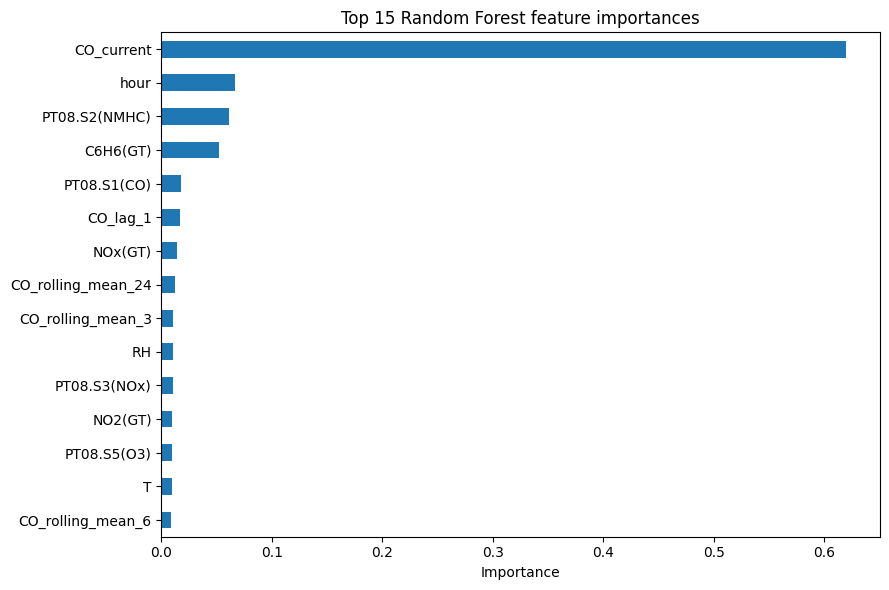

In [23]:
rf = model.named_steps["regressor"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importance.head(15).to_frame("importance"))
importance.head(15).sort_values().plot(kind="barh", figsize=(9, 6), title="Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Findings, limitations, and next steps
Fill in the statements below after inspecting the outputs. Do not claim numerical results until the notebook has been run.

### Findings (complete from your run)
1. Describe the missingness pattern and the effect of converting `-200` to missing.
2. State the observed long-term or daily pattern in CO(GT).
3. Report the Random Forest test MAE and RMSE, compared with the mean baseline.
4. Identify the strongest model features and explain their plausible relationship to next-hour CO.
5. Describe whether large residuals cluster at peaks, abrupt changes, or particular periods.
6. State the test-period R² and what it says about predictive performance.

### Limitations
- The dataset is historical and from one monitoring location/time period, so generalization to other locations is uncertain.
- Sensor readings and the ground-truth target contain missing values; imputation can reduce fidelity.
- Random Forest does not naturally extrapolate trends and the model predicts only one step ahead.

### Possible improvement
Use time-series cross-validation and compare against persistence/seasonal-naive baselines, then evaluate a carefully tuned gradient-boosting or sequence model.

## 11. Export cleaned data and model results

In [24]:
clean_export = df.copy()
clean_export.to_csv("air_quality_cleaned.csv", index=False)
results.to_csv("air_quality_model_metrics.csv")
print("Saved: air_quality_cleaned.csv and air_quality_model_metrics.csv")

Saved: air_quality_cleaned.csv and air_quality_model_metrics.csv
